In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [27]:
#Load crap
GEN_PATH = "../../assets/03/gen/"
img = cv2.imread("../../assets/03/HALO_3_src.jpg")

#Process all. GrayScale, Blur (Gaussian), Sobel, Laplace

#Grayscale conversion
img_gs = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Gaussian Blur and GrayScale. Doesn't fuck up the colors. Used in the next processing steps. Noise Reduction.
img_gsblur = cv2.GaussianBlur(img_gs, (5, 5), 0)

#Edge Detection.

#Sobel X & Y gradients
img_grad_sobx = cv2.Sobel(img_gsblur, cv2.CV_64F, 1, 0, ksize = 5) 
img_grad_soby = cv2.Sobel(img_gsblur, cv2.CV_64F, 0, 1, ksize = 5) 

abs_sobx = cv2.convertScaleAbs(img_grad_sobx)
abs_soby = cv2.convertScaleAbs(img_grad_soby)

#SOBEL
img_sobel = cv2.addWeighted(abs_sobx, 0.5, abs_soby, 0.5, 0)

#BINARIZATION (OTSU). Aut threshold val.
_, th_otsu = cv2.threshold(img_sobel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#OPTIMIZATION: MORPHOLOGICAL OPENING (Erosion followed by Dilation)
#Breaks small connections between foreground and background noise.
#Sierra 117 contours not connected to sky anymore.
ker = np.ones((3, 3), np.uint8) # Small kernel for subtle cleaning
th_otsucl = cv2.morphologyEx(th_otsu, cv2.MORPH_OPEN, ker, iterations = 1)

#CONTOURS
#contours, _ = cv2.findContours(th_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) No opt. applied.
contours, _ = cv2.findContours(th_otsucl, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#Draw results
img_ctrs = img.copy() 

for c in contours:
    
    area = cv2.contourArea(c)
    #Discard crap less than this. Assume is noise (Ark, Sky reflects etc).
    #100k. Only captures Sierra 117.
    if area < 100000:
        continue

    perimeter = cv2.arcLength(c, True)

    #Moments, Centroids.
    M = cv2.moments(c)
    if M["m00"] > 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        continue

    #Bounding Box
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(img_ctrs, (x, y), (x + w, y + h), (0, 255, 0), 2)

    #Draw Centroid
    cv2.circle(img_ctrs, (cX, cY), 5, (0, 0, 255), -1)

    #Dibujar Contour
    cv2.drawContours(img_ctrs, [c], -1, (255, 0, 0), 2)

    text = f"Area: {int(area)} | Perimeter: {int(perimeter)}"
    
    cv2.putText(img_ctrs, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

cv2.imwrite(f"{GEN_PATH}contours.png", img_ctrs)

True

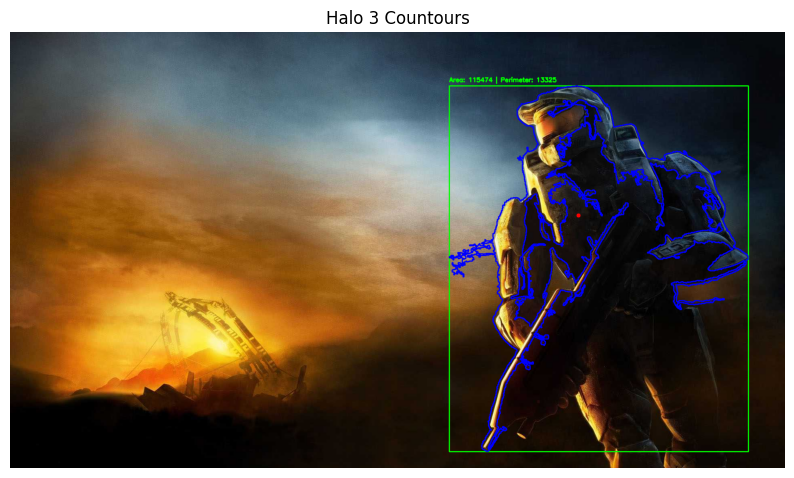

In [28]:
#DISPLAY CRAP
img_display = cv2.cvtColor(img_ctrs, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (10, 8))
plt.imshow(img_display)
plt.title("Halo 3 Countours")
plt.axis('off')

plt.show()